In [1]:
TRANSFER_MODE = "Serial"

In [1]:
TRANSFER_MODE = "SD"

In [2]:
import re
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
import ipdb
from ipywidgets import IntProgress
from IPython.display import display
from math import floor
from datetime import datetime
# --- Configuration ---
SERIAL_PORT = "COM8"  # Replace with your serial port (e.g., "/dev/ttyUSB0" on Linux)
BAUD_RATE = 115200    # Adjust to match your device's baud rate
OUTPUT_FILE = "serial_output.txt"  # File to save the serial stream


# --- Extract histograms from text ---
def extract_histograms(text):
    pattern = r"B (\d+)\s*(.*?)\s*E \d+"
    histograms = []

    for match in re.finditer(pattern, text, re.DOTALL):
        pixel = int(match.group(1))
        histogram_lines = match.group(2).strip().split("\n")

        histogram = []
        for line in histogram_lines:
            values = list(map(int, line.strip().split("_")))
            histogram.extend(values)

        histograms.append(np.array(histogram))

    return histograms

def stream_serial_to_file(port, baud_rate, output_file, pixels, timeout=10):
    """
    Stream serial data to a file and stop if "DONE" is encountered or timeout expires.

    Args:
        port (str): Serial port (e.g., "COM3" or "/dev/ttyUSB0").
        baud_rate (int): Baud rate (e.g., 115200).
        output_file (str): Path to the output file.
        timeout (int): Maximum time (seconds) to wait for data before stopping.

    Returns:
        bool: True if "DONE" was encountered, False if timeout expired.
    """


    max_count = 1000

    bar = IntProgress(min=0, max=max_count) # instantiate the bar
    display(bar) # display the bar


    
    first = True
    begin_numbers = False
    try:
        with serial.Serial(port, baud_rate, timeout=timeout) as ser, \
             open(output_file, "w") as f:
            print(f"Streaming serial data from {port} to {output_file}...")
            start_time = time.time()

            while True:
                if ser.in_waiting:
                    if(first == True):
                        print("beginning of stream");
                        print("\n\r");
                        first = False
                    line = ser.readline().decode("utf-8", errors="ignore").strip()
                    if line:  # Skip empty lines
                        if(line.startswith("B 0")):
                            begin_numbers = True
                            t_begin = time.time()
                            #ipdb.set_trace()
                            
                        if(begin_numbers==False):
                            print(line)
                            if line.startswith("the specified bin width is: "):
                                global bin_width
                                bin_width = int((line.split(" ")[5]).replace("ps", ""))
                                print(f"bin_width: {bin_width}")
                        else:
                            if line.startswith("B "):
                                pixel_num = line.split(" ")[1]
                                progress = floor(int(pixel_num)/pixels*max_count)
                                bar.value = progress
                                if line == "B 100":
                                    t_100 = time.time()
                                    dt_100 = t_100 - t_begin
                                    dt_end = dt_100 * pixels/100.0
                                    t_end = t_begin + dt_end
                                    formatted_end_time = datetime.fromtimestamp(t_end).strftime('%H:%M:%S')
                                    formatted_total_time = datetime.fromtimestamp(dt_end).strftime('%H:%M:%S')

                                    hours = int(dt_end // 3600)
                                    minutes = int((dt_end - hours*3600) //60)
                                    seconds = int(dt_end - hours * 3600 - minutes * 60)
                                    #ipdb.set_trace()
                                    #current_time = end_time.strftime("%H:%M:%S")
                                    #print("Receiving this image should take: " + formatted_total_time + "\r\n")
                                    print("Receiving this image should take: " + f"{hours}h, {minutes}m, {seconds}s." + "\r\n")
                                    print(f"it should be done at: "  + formatted_end_time + "\r\n")
                                    #print(f"dt_end: {dt_end}")
                                    #print(f"pixels:  {pixels}")
                                    
                                
                            f.write(line + "\n")
                            f.flush()  # Ensure data is written immediately
                            #print(line)  # Optional: Print to console for debugging
                            


                            # Check for "DONE" (case-insensitive)
                            if "DONE" in line:
                                print("Found 'DONE' in serial output. Stopping stream.")
                                return True

                # Exit after timeout (seconds) if no data is received
                if timeout and (time.time() - start_time) > timeout:
                    print("Timeout reached. Stopping serial stream.")
                    return False

    except serial.SerialException as e:
        print(f"Serial error: {e}")
        return False
    except KeyboardInterrupt:
        print("Stopped by user.")
        return False




def plot_histograms_as_image_argmax(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the index of the maximum bin in its histogram.

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint32)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue



        # Find the index of the maximum bin value
        max_bin_index = np.argmax(histogram)
        
        max_bin_ps = max_bin_index * bin_width  # convert from bins to ps

        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        #normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(max_bin_ps)
        
                # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width
        #image[row, col] = pixel_values[pixel]*255/max_value
        image[row, col] = max_bin_ps

        
    max_value = max(pixel_values)
    min_value = min(pixel_values)
        


    # Plot the image
    plt.figure(figsize = (20,20))
    #plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
    plt.imshow(image, cmap="gray", vmin=min_value, vmax=max_value)
    plt.colorbar(label="Maximum Bin (ps)")
    plt.title("Image Reconstructed from Histograms")
    plt.show()

    return image


def median_bin_interpolated(bins, counts):
    total = np.sum(counts)
    target = 0.5 * total
    cum_counts = np.cumsum(counts)
    # Find the bin where cumulative count crosses target
    median_bin_index = np.argmax(cum_counts >= target)
    if cum_counts[median_bin_index] == target:
        # Exact match: median is the upper edge of the bin
        return median_bin_index, bins[median_bin_index + 1]
    else:
        # Interpolate within the bin
        counts_so_far = cum_counts[median_bin_index - 1] if median_bin_index > 0 else 0
        count_in_bin = counts[median_bin_index]
        fraction = (target - counts_so_far) / count_in_bin
        lower_edge = bins[median_bin_index]
        upper_edge = bins[median_bin_index + 1]
        median_value = lower_edge + fraction * (upper_edge - lower_edge)
        return median_bin_index, median_value


def plot_histograms_as_image_center_of_mass(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the index of the center of mass of its histogram.

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint32)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width

        # Find the index of the maximum bin value
        #max_bin_index = np.argmax(histogram)
        
        weights = np.array(histogram)
        bins = np.arange(histogram.size)
        
        _, CoM = median_bin_interpolated(bins, weights)
        
        CoM = CoM * bin_width  # convert from bins to ps

        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        #normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(CoM)
        image[row, col] = CoM

    # Plot the image
    plt.figure(figsize = (20,20))
    plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
   #plt.imshow(image, cmap="gray", vmin=min(pix, vmax=255)
    plt.colorbar(label="Center of Histogram Mass (ps)")
    plt.title("Image Reconstructed from Histograms")
    plt.show()

    return image   



from scipy.optimize import curve_fit
from scipy.signal import convolve
import matplotlib.pyplot as plt

def shift_time(counts: np.ndarray):
    """Shift time point 0 to the maximum of the decay

    Args:
        time : array of time bins
        decay : array of intensity values (counts) of the decay

    Returns:
        shifted array of time bins
    """
    #return time - time[np.argmax(counts)]
    argmax = np.argmax(counts)
    return np.concatenate((counts[argmax:],counts[:argmax]))

# --- Define the IRF (Gaussian) ---
def irf(t, mu=0, sigma=0.1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((t - mu) / sigma) ** 2)

def ideal_decay(t, A, tau_decay, B):
    signal = A * np.exp(-(t)/tau_decay) + B
    return signal

# --- Convolve the ideal signal with the IRF ---
def convolved_model(t, A, tau_decay, B, sigma=0.1):
    t_fine = np.linspace(t.min(), t.max(), 1000)
    #signal_fine = ideal_signal(t_fine, A, t0, tau_rise, tau_decay, B)
    signal_fine = ideal_decay(t_fine, A, tau_decay, B)

    irf_fine = irf(t_fine, sigma=sigma)
    irf_fine /= irf_fine.sum()  # Normalize
    convolved = convolve(signal_fine, irf_fine, mode='same')
    return np.interp(t, t_fine, convolved)


def fit_histogram(histogram):
    
    
    guess_tau_decay = 2.5  # True tau for simulation
    guess_A = 1000
    guess_B = 10
    histogram_shifted = shift_time(histogram)
    #time_bins = np.linspace(0, 10, 200)
    time_bins = np.arange(histogram.size)
    
    # --- Fit the convolved model ---
    popt, pcov = curve_fit(
        lambda t, A, tau_decay, B: convolved_model(t, A, tau_decay, B, sigma=0.1),
        time_bins,
        histogram_shifted,
        p0=[guess_A, guess_tau_decay, guess_B]  # Initial guess
    )

    A_fit, tau_decay_fit, B_fit = popt
    
    return tau_decay_fit

def plot_histograms_as_image_tau_fit(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the fitted exponential lifetime of its histogram.

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint32)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width
        
        
        
        # Find the index of the maximum bin value
        #max_bin_index = np.argmax(histogram)
        tau_pixel = fit_histogram(np.array(histogram))
        
        tau_pixel = tau_pixel * bin_width # bins to ps conversion
        
        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        #normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(tau_pixel)
        image[row, col] = tau_pixel

    # Plot the image
    plt.figure(figsize = (20,20))
    plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
    plt.colorbar(label="Fitted Fluorescence Lifetime (ps)")
    plt.title("Image Reconstructed from Histograms")
    plt.show()

    return image   

In [3]:
# --- Main workflow ---
frame_width = 16
# Step 1: Stream serial data to file
if TRANSFER_MODE == "Serial":
    stream_serial_to_file(SERIAL_PORT, BAUD_RATE, OUTPUT_FILE, frame_width*frame_width, timeout=3000000000000)
elif TRANSFER_MODE == "SD":
    stream_serial_to_file(SERIAL_PORT, BAUD_RATE, "waste.txt", frame_width*frame_width, timeout=3000000000000)

IntProgress(value=0, max=1000)

Streaming serial data from COM8 to waste.txt...
beginning of stream


------------------------------------------------------------
----------- GPX2_LVDS_READOUT -----------
------------------------------------------------------------
System ready.
Current Settings are expecting a reference clock frequency of 10000 kHz.
Currently listening for STOP signals on channel 1.
the expected laser clock period is: 100000 ps.
the specified bin width is: 32 ps.
bin_width: 32
the histogram will be 3132 bins wide.
Successfully wrote 64 words to BRAM
Acquiring Image took 1104 ms.
Safe to remove SD Card...
Found 'DONE' in serial output. Stopping stream.


In [4]:
if TRANSFER_MODE == "SD":
    import shutil
    shutil.copyfile("D:/HIST.TXT", "serial_output.txt")

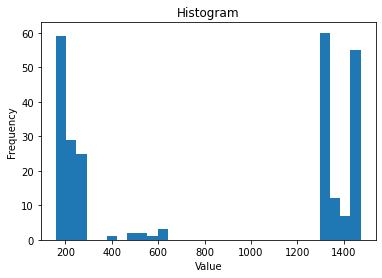

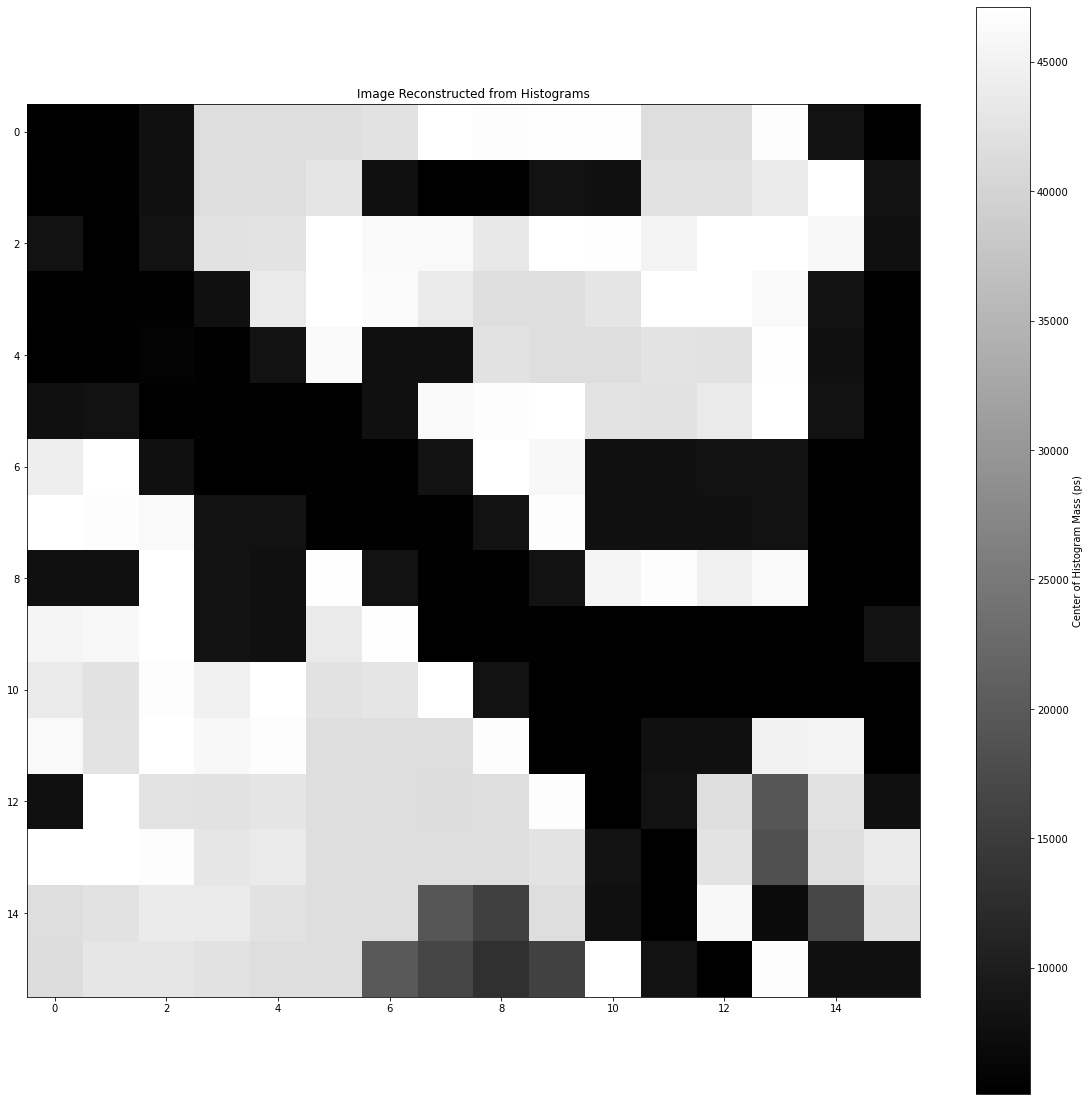

In [5]:
# Step 2: Read the file and extract histograms
with open(OUTPUT_FILE, "r") as f:
    serial_output = f.read()

histograms = extract_histograms(serial_output)

CoMs = []

for index, hist in enumerate(histograms):
    
    weights = np.array(hist)
    bins = np.arange(hist.size)

    _, CoM = median_bin_interpolated(bins, weights)   
    CoMs.append(CoM)

import numpy as np
import matplotlib.pyplot as plt

data = CoMs

plt.hist(data, bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

#slow clock 3 tap
image = plot_histograms_as_image_center_of_mass(histograms,frame_width)

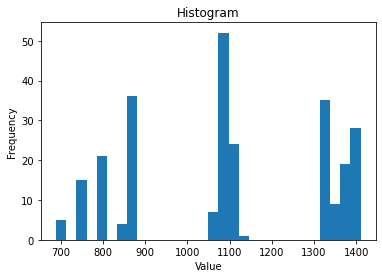

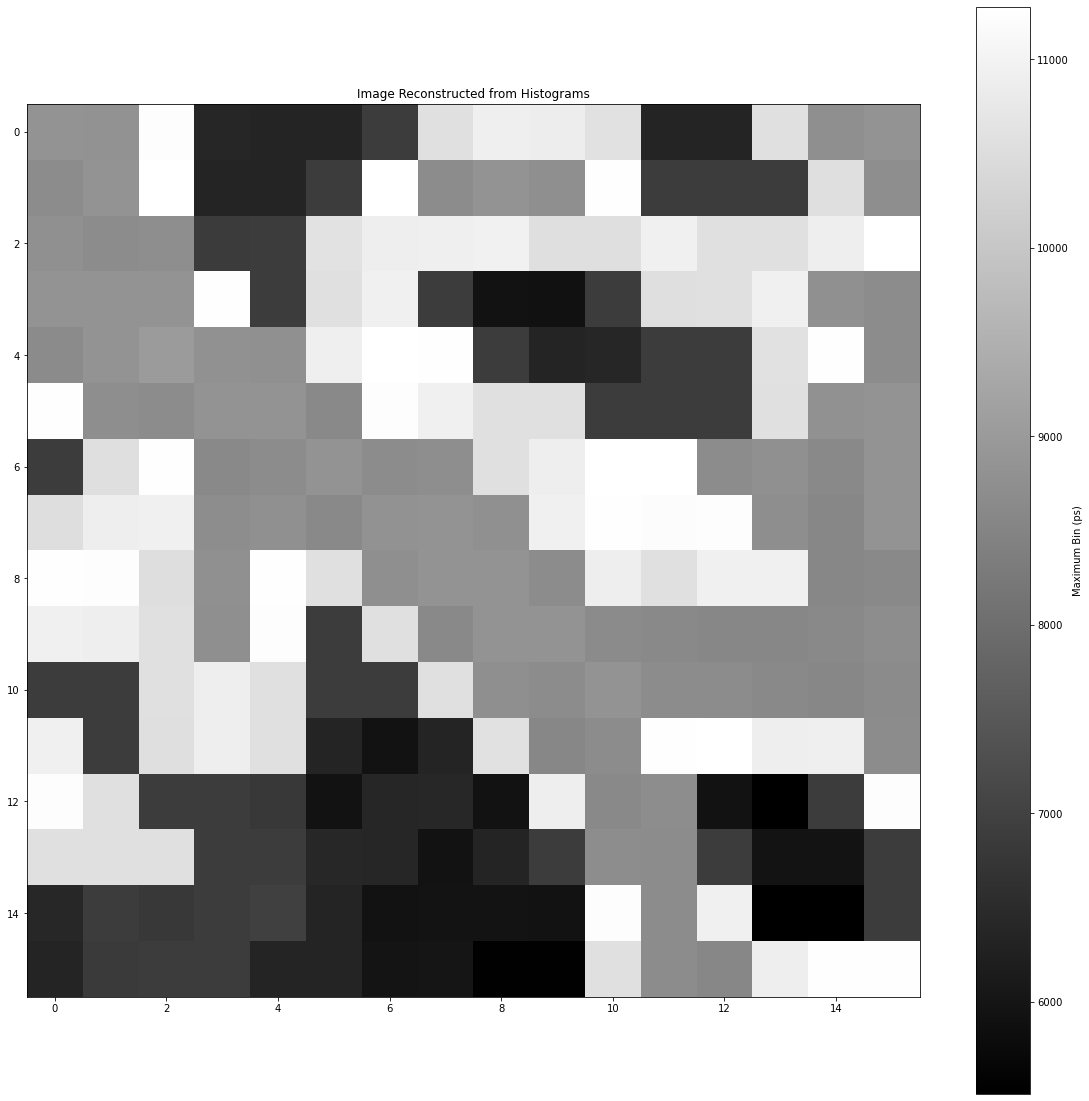

37.5390625


In [51]:
# Step 2: Read the file and extract histograms
with open(OUTPUT_FILE, "r") as f:
    serial_output = f.read()

histograms = extract_histograms(serial_output)

argmaxes = []

for index, hist in enumerate(histograms):
    argmaxes.append(np.argmax(hist))
    #if np.argmax(hist) > 32:
       # print(index, np.argmax(hist))

import numpy as np
import matplotlib.pyplot as plt

data = argmaxes

plt.hist(data, bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

#slow clock 3 tap
image = plot_histograms_as_image_argmax(histograms,frame_width)

total_nonempty_bins = 0
for pixel, hist in enumerate(histograms):
    nonempty_bins = np.count_nonzero(hist)
    total_nonempty_bins += nonempty_bins
print(total_nonempty_bins/(frame_width*frame_width))

C:\Users\marce\anaconda3\lib\site-packages\scipy\optimize\minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


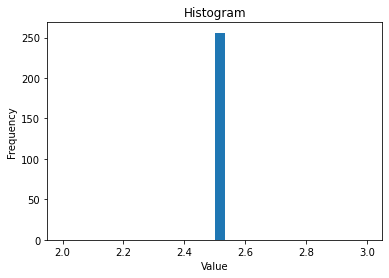

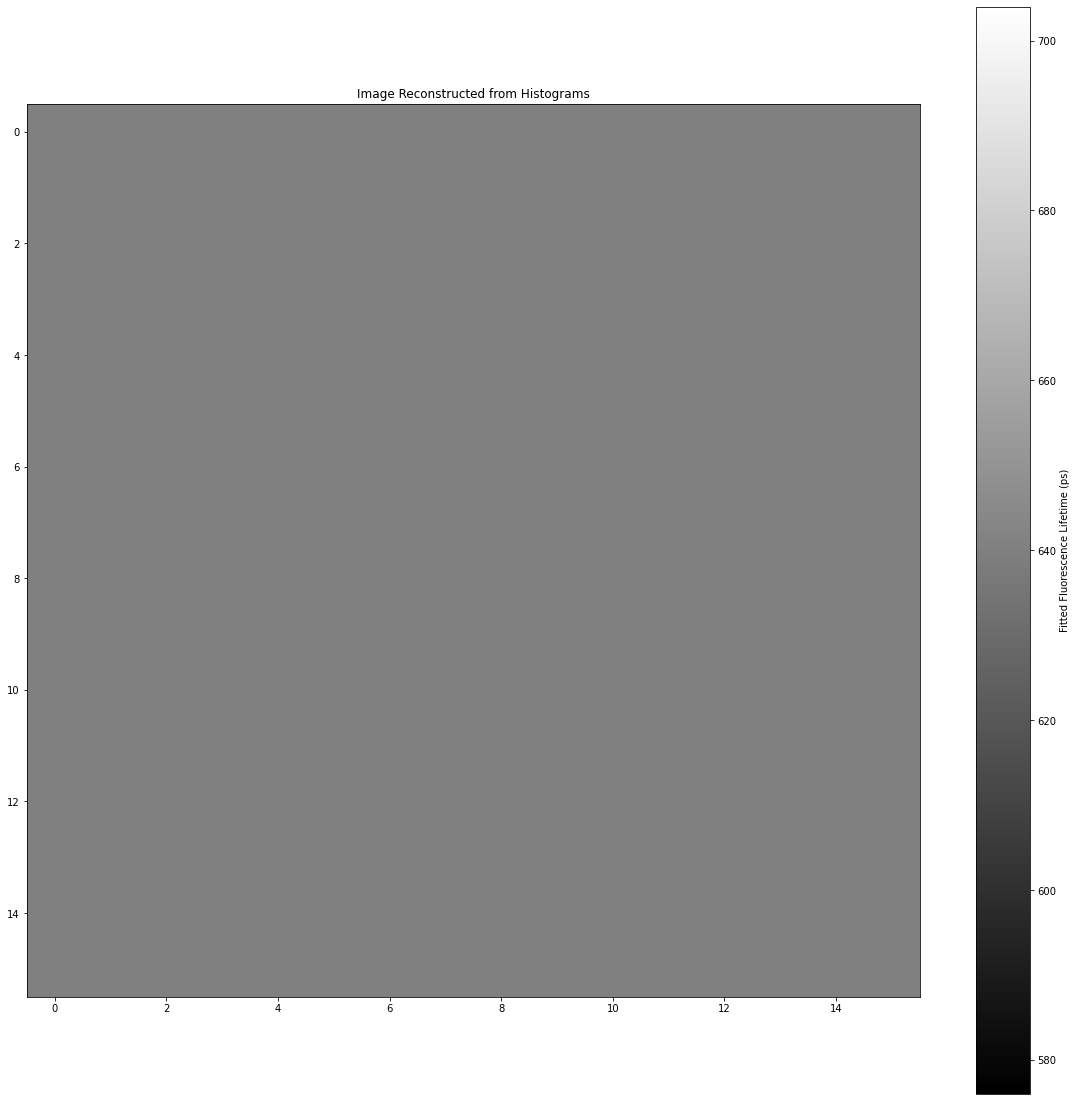

In [43]:
# Step 2: Read the file and extract histograms
with open(OUTPUT_FILE, "r") as f:
    serial_output = f.read()

histograms = extract_histograms(serial_output)

taus = []

for index, hist in enumerate(histograms):
    tau = fit_histogram(hist)
    taus.append(tau)


import numpy as np
import matplotlib.pyplot as plt

data = taus

plt.hist(data, bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

#slow clock 3 tap
image = plot_histograms_as_image_tau_fit(histograms,frame_width)

Fitted tau: 2.482


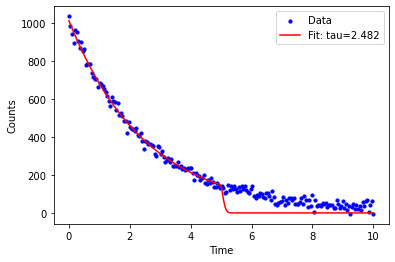

In [17]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import convolve
import matplotlib.pyplot as plt

# --- Example histogram data ---
time_bins = np.linspace(0, 10, 200)  # Time bins
true_tau = 2.5  # True tau for simulation
true_A = 1000
true_B = 10
counts = true_A * np.exp(-time_bins / true_tau) + true_B + np.random.normal(0, 20, len(time_bins))

# --- Define the IRF (Gaussian) ---
def irf(t, mu=0, sigma=0.1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((t - mu) / sigma) ** 2)

# --- Define the exponential decay ---
def exponential_decay(t, A, tau, B):
    return A * np.exp(-t / tau) + B

# --- Convolve the decay with the IRF ---
def convolved_model(t, A, tau, B, sigma=0.1):
    # Create a fine grid for convolution
    t_fine = np.linspace(t.min(), t.max(), 1000)
    decay_fine = exponential_decay(t_fine, A, tau, B)
    irf_fine = irf(t_fine, sigma=sigma)

    # Normalize the IRF
    irf_fine /= irf_fine.sum()

    # Convolve
    convolved = convolve(decay_fine, irf_fine, mode='same')
    # Interpolate back to original time bins
    return np.interp(t, t_fine, convolved)

# --- Fit the convolved model ---
popt, pcov = curve_fit(
    lambda t, A, tau, B: convolved_model(t, A, tau, B, sigma=0.1),
    time_bins,
    counts,
    p0=[true_A, true_tau, true_B]  # Initial guess
)

A_fit, tau_fit, B_fit = popt
print(f"Fitted tau: {tau_fit:.3f}")

# --- Plot ---
plt.scatter(time_bins, counts, label="Data", color="blue", s=10)
plt.plot(time_bins, convolved_model(time_bins, *popt, sigma=0.1), label=f"Fit: tau={tau_fit:.3f}", color="red")
plt.xlabel("Time")
plt.ylabel("Counts")
plt.legend()
plt.show()

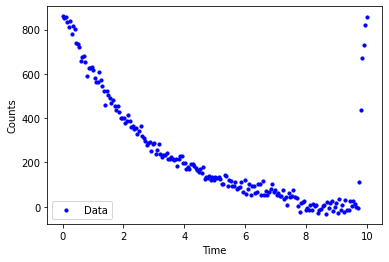

In [35]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import convolve
import matplotlib.pyplot as plt

# --- Example histogram data ---
time_bins = np.linspace(0, 10, 200)
true_t0 = 2.0
#true_tau_rise = 0.2
true_tau_decay = 2.5
true_A = 1000
true_B = 10
true_tau_rise = 0.1  # Small rise time (almost step-like)

# Simulate the signal: step at t0, then exponential decay
def ideal_signal(t, A, t0, tau_rise, tau_decay, B):
    mask = (t >= t0)
    signal = np.zeros_like(t)
    signal[mask] = A * (1 - np.exp(-(t[mask] - t0)/tau_rise)) * np.exp(-(t[mask] - t0)/tau_decay) + B
    return signal

def ideal_decay(t, A, tau_decay, B):
    signal = A * np.exp(-(t)/tau_decay) + B
    return signal

# Add noise
counts = ideal_signal(time_bins, true_A, true_t0, true_tau_rise, true_tau_decay, true_B) + np.random.normal(0, 20, len(time_bins))
counts_shifted = shift_time(counts)
plt.scatter(time_bins, counts_shifted, label="Data", color="blue", s=10)
#plt.plot(time_bins, convolved_model(time_bins, *popt, sigma=0.1), label=f"Fit: t0={t0_fit:.2f}, tau={tau_decay_fit:.2f}", color="red")
plt.xlabel("Time")
plt.ylabel("Counts")
plt.legend()
plt.show()

Fitted t0: 2.207, tau_decay: 2.462


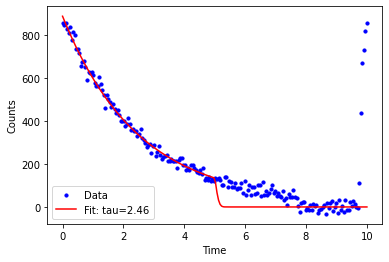

In [39]:
# --- Define the IRF (Gaussian) ---
def irf(t, mu=0, sigma=0.1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((t - mu) / sigma) ** 2)

# --- Convolve the ideal signal with the IRF ---
def convolved_model(t, A, tau_decay, B, sigma=0.1):
    t_fine = np.linspace(t.min(), t.max(), 1000)
    #signal_fine = ideal_signal(t_fine, A, t0, tau_rise, tau_decay, B)
    signal_fine = ideal_decay(t_fine, A, tau_decay, B)

    irf_fine = irf(t_fine, sigma=sigma)
    irf_fine /= irf_fine.sum()  # Normalize
    convolved = convolve(signal_fine, irf_fine, mode='same')
    return np.interp(t, t_fine, convolved)

# --- Fit the convolved model ---
popt, pcov = curve_fit(
    lambda t, A, tau_decay, B: convolved_model(t, A, tau_decay, B, sigma=0.1),
    time_bins,
    counts_shifted,
    p0=[true_A, true_tau_decay, true_B]  # Initial guess
)

A_fit, tau_decay_fit, B_fit = popt
print(f"Fitted t0: {t0_fit:.3f}, tau_decay: {tau_decay_fit:.3f}")

# --- Plot ---
plt.scatter(time_bins, counts_shifted, label="Data", color="blue", s=10)
plt.plot(time_bins, convolved_model(time_bins, *popt, sigma=0.1), label=f"Fit: tau={tau_decay_fit:.2f}", color="red")
plt.xlabel("Time")
plt.ylabel("Counts")
plt.legend()
plt.show()

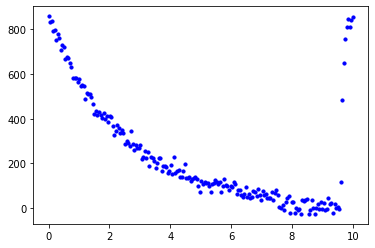

In [25]:
plt.scatter(time_bins, counts_shifted, label="Data", color="blue", s=10)


In [7]:
plot_histograms_as_image_tau_fit(histograms, 256)

NameError: name 'shift_time' is not defined